In [1]:
import os
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# 1. Khởi tạo bộ tăng cường dữ liệu cho tập Train
train_datagen = ImageDataGenerator(
    rescale=1./255,             # Chuẩn hóa giá trị pixel về [0, 1]
    rotation_range=40,          # Xoay ảnh ngẫu nhiên tối đa 40 độ
    width_shift_range=0.2,      # Dịch chuyển ảnh theo chiều ngang
    height_shift_range=0.2,     # Dịch chuyển ảnh theo chiều dọc
    shear_range=0.2,            # Làm méo ảnh
    zoom_range=0.2,             # Phóng to/thu nhỏ ngẫu nhiên
    horizontal_flip=True,       # Lật ảnh ngang
    fill_mode='nearest'         # Lấp đầy các pixel trống sau khi biến đổi
)

val_datagen = ImageDataGenerator(rescale=1./255)

# 2. Tạo generator đọc dữ liệu từ thư mục
base_dir = r'C:\Users\ADMIN\Documents\archive\Rock-Paper-Scissors\Rock-Paper-Scissors'
train_dir = os.path.join(base_dir, 'train')
val_dir = os.path.join(base_dir, 'validation')
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical'
)

val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='categorical'
)

Found 2520 images belonging to 3 classes.
Found 33 images belonging to 3 classes.


In [2]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

# 1. Khởi tạo mô hình
model = Sequential([
    # Lớp tích chập 1
    Conv2D(32, (3,3), activation='relu', input_shape=(150, 150, 3)),
    MaxPooling2D(2, 2),
    
    # Lớp tích chập 2
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    
    # Lớp tích chập 3
    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    
    # Lớp tích chập 4
    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    
    # Dàn phẳng dữ liệu để đưa vào lớp Dense
    Flatten(),
    Dropout(0.5), # Kỹ thuật Dropout giúp giảm Overfitting
    
    # Lớp ẩn (Hidden layer)
    Dense(512, activation='relu'),
    
    # Lớp đầu ra (Output layer): 3 node tương ứng với 3 class, dùng softmax
    Dense(3, activation='softmax') 
])

# 2. Compile mô hình
model.compile(
    loss='categorical_crossentropy', 
    optimizer='adam', 
    metrics=['accuracy']
)

# Xem tóm tắt kiến trúc mạng
model.summary()

c:\Users\ADMIN\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 15, 15, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     3,211,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │         1,539 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,454,147 (13.18 MB)

 Trainable params: 3,454,147 (13.18 MB)

 Non-trainable params: 0 (0.00 B)

In [3]:
history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // 32,
    epochs=15,
    validation_data=val_generator,
    validation_steps=val_generator.samples // 32
)

Epoch 1/15
78/78 ━━━━━━━━━━━━━━━━━━━━ 42s 522ms/step - accuracy: 0.4268 - loss: 1.0407 - val_accuracy: 0.7500 - val_loss: 0.5421
Epoch 2/15
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5312 - loss: 0.9998 - val_accuracy: 0.7500 - val_loss: 0.5067
Epoch 3/15


c:\Users\ADMIN\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\trainers\epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


78/78 ━━━━━━━━━━━━━━━━━━━━ 23s 292ms/step - accuracy: 0.7231 - loss: 0.6351 - val_accuracy: 0.9062 - val_loss: 0.1740
Epoch 4/15
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9062 - loss: 0.3633 - val_accuracy: 0.9062 - val_loss: 0.2294
Epoch 5/15
78/78 ━━━━━━━━━━━━━━━━━━━━ 23s 289ms/step - accuracy: 0.8698 - loss: 0.3324 - val_accuracy: 1.0000 - val_loss: 0.0451
Epoch 6/15
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8750 - loss: 0.3354 - val_accuracy: 1.0000 - val_loss: 0.0374
Epoch 7/15
78/78 ━━━━━━━━━━━━━━━━━━━━ 22s 286ms/step - accuracy: 0.9208 - loss: 0.2303 - val_accuracy: 0.9062 - val_loss: 0.1498
Epoch 8/15
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9375 - loss: 0.2030 - val_accuracy: 0.9062 - val_loss: 0.1561
Epoch 9/15
78/78 ━━━━━━━━━━━━━━━━━━━━ 22s 282ms/step - accuracy: 0.9329 - loss: 0.1874 - val_accuracy: 0.9375 - val_loss: 0.2125
Epoch 10/15
78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9375 - loss: 0.2124 - val_accuracy: 0.9375 - val_los

In [4]:
test_dir = os.path.join(base_dir, 'test')
test_datagen = ImageDataGenerator(rescale=1./255)
test_generator = test_datagen.flow_from_directory(
    test_dir,                   
    target_size=(150, 150),     # Ép ảnh về đúng 150x150 như lúc huấn luyện
    batch_size=32,
    class_mode='categorical',
    shuffle=False               # BẮT BUỘC PHẢI LÀ FALSE ĐỂ VẼ MA TRẬN KHÔNG BỊ SAI
)

Found 372 images belonging to 3 classes.



--- 1. KẾT QUẢ TỔNG QUAN ---
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 260ms/step - accuracy: 0.9785 - loss: 0.0484
Test Accuracy: 97.85%

Đã lưu mô hình thành công với tên: rps_cnn_v2_98pct.keras

--- 2. VẼ MA TRẬN NHẦM LẪN (CONFUSION MATRIX) ---
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 77ms/step


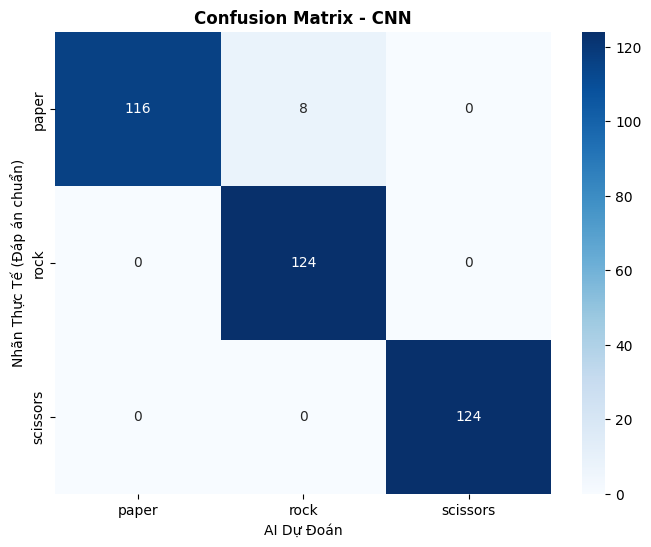


--- 3. BÁO CÁO CHI TIẾT ---
              precision    recall  f1-score   support

       paper       1.00      0.94      0.97       124
        rock       0.94      1.00      0.97       124
    scissors       1.00      1.00      1.00       124

    accuracy                           0.98       372
   macro avg       0.98      0.98      0.98       372
weighted avg       0.98      0.98      0.98       372



In [5]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

print("\n--- 1. KẾT QUẢ TỔNG QUAN ---")
# Đánh giá trên tập test
test_loss, test_accuracy = model.evaluate(test_generator)
print(f"Test Accuracy: {test_accuracy*100:.2f}%")

# 2. LƯU MÔ HÌNH 
model_name = f'rps_cnn_v2_{test_accuracy*100:.0f}pct.keras' 
model.save(model_name)
print(f"\nĐã lưu mô hình thành công với tên: {model_name}")

print("\n--- 2. VẼ MA TRẬN NHẦM LẪN (CONFUSION MATRIX) ---")
# Tập test_generator của bạn BẮT BUỘC phải cài đặt shuffle=False
predictions = model.predict(test_generator)
y_pred = np.argmax(predictions, axis=1) # Chuyển xác suất thành nhãn AI đoán
y_true = test_generator.classes         # Nhãn đáp án thật

# Lấy tên các class (Paper, Rock, Scissors)
class_names = list(test_generator.class_indices.keys())

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - CNN', fontweight='bold')
plt.ylabel('Nhãn Thực Tế (Đáp án chuẩn)')
plt.xlabel('AI Dự Đoán')
plt.show()

print("\n--- 3. BÁO CÁO CHI TIẾT ---")
print(classification_report(y_true, y_pred, target_names=class_names))